---

# Notes on Statistically Simulating the GWB

---

## Python Setup

This lets me time how long the notebook takes to run. Included before imports so those are counted in the time.

In [1]:
from time import perf_counter 
t0 = perf_counter()

General Python package imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from scipy.interpolate import interp1d
import gc

## Simulation Setup

These are parameters that the user will define

In [3]:
# Seed used for any random generations
RANDOM_SEED = 42
# Number of pulsars
N_PSR = 67
# log_10(A_GWB)
LOG10A_GWB = -15.0
# gamma_GWB
GAMMA_GWB = 13.0 / 3.0
# Duration of the observation
OBS_DUR = 15 * u.yr
# Number of TOAs
N_TOA = 100_000
# Number of points in time for GWB
N_TIMES = 200
# Number of frequencies
N_FREQS = 100
# Reference frequency
REF_FREQ = 1 / u.yr
# Number of frequency bins for HD curve
N_HD_BINS = 10

Parameters derived from user-supplied ones

In [4]:
A_GWB = 10**LOG10A_GWB
ALPHA_GWB = -0.5 * (GAMMA_GWB - 3)

Define a random number generator based on the given `RANDOM_SEED`

In [5]:
rng = np.random.default_rng(RANDOM_SEED)

## Step 1: Load (or Create) Sources

Here, we create a set of `N_PSR` total pulsars, each with a position on the sky defined by a polar angle $\theta\in[0, \pi]$ and azimuthal angle $\phi\in[0,2\pi]$.

In [6]:
theta = rng.uniform(0, np.pi, N_PSR)
phi = rng.uniform(0, 2 * np.pi, N_PSR)
print(f"theta shape should be ({N_PSR},): {theta.shape}")
print(f"phi shape should be ({N_PSR},): {phi.shape}")

theta shape should be (67,): (67,)
phi shape should be (67,): (67,)


Plot the sky positions, shifting the angles for `matplotlib` such that $\theta\in[-\frac{\pi}{2}, \frac{\pi}{2}]$ and $\phi\in[-\pi,\pi]$

In [7]:
phi_mpl = phi-np.pi
theta_mpl = theta-np.pi/2

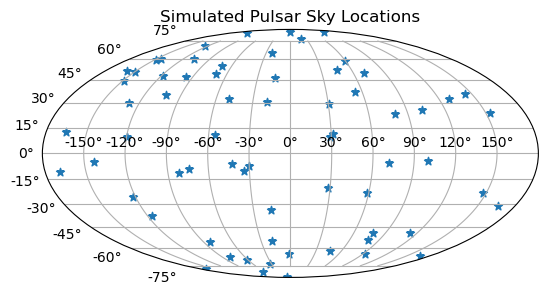

In [8]:
plt.figure()
plt.subplot(projection="mollweide")
plt.scatter(
    phi_mpl, 
    theta_mpl, 
    marker = "*",
    )
plt.title("Simulated Pulsar Sky Locations")
plt.grid(True)

Compute the Cartesian unit vectors corresponding to those sky positions

In [9]:
p = np.column_stack([
        np.sin(theta) * np.cos(phi),
        np.sin(theta) * np.sin(phi),
        np.cos(theta)
    ])
print(f"p shape should be ({N_PSR}, 3): {p.shape}")

p shape should be (67, 3): (67, 3)


Define a sphere on which to plot the points

In [10]:
phi_sph, theta_sph = np.mgrid[0:2*np.pi:101j, 0:np.pi:101j]
x_sph = np.sin(theta_sph) * np.cos(phi_sph)
y_sph = np.sin(theta_sph) * np.sin(phi_sph)
z_sph = np.cos(theta_sph)

Plot the Cartesian points on a unit sphere

[BUG] Matplotlib has trouble with z-ordering in 3D, [see here](https://stackoverflow.com/questions/31768031/plotting-points-on-the-surface-of-a-sphere)

Text(0.5, 0.92, 'Pulsar Locations (Cartesian)')

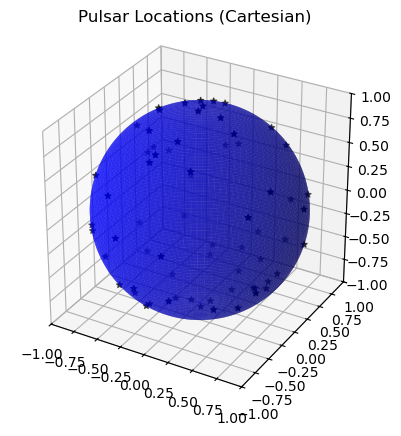

In [11]:
# Init figure
fig = plt.figure()
# Add 3D axis
ax = fig.add_subplot(111, projection='3d')
# Define current axis
cax = ax
# Plot the sphere
cax.plot_surface(
    x_sph, y_sph, z_sph,  
    rstride=1, cstride=1, color='b', alpha=0.6, linewidth=0
    )
# Plot the stars
cax.scatter(
    p[:,0], p[:,1], p[:,2],
    color="k", s=20, marker = "*",
    )

# Square the axes
cax.set_xlim([-1,1])
cax.set_ylim([-1,1])
cax.set_zlim([-1,1])
cax.set_aspect("equal")

# Set a title
cax.set_title("Pulsar Locations (Cartesian)")

## Step 2: Generate time and frequency lists

[TODO] Add option for padding the times (e.g. 1 day on either side)

In [12]:
# Convert given observation duration to seconds
obs_dur_s = OBS_DUR.to(u.s)
# Make a list of times
t = np.linspace(0, obs_dur_s, N_TIMES)
# Check the shape of the result ([TODO] Unit test)
print(f"t shape should be ({N_TIMES},): {t.shape}")

t shape should be (200,): (200,)


In [13]:
# Time step between points
dt = obs_dur_s / (N_TIMES-1)
# Nyquist frequency
f_nyquist = 1 / (2*dt)
# Define a range of frequencies
f = np.linspace(0, f_nyquist, N_FREQS+1)
# Remove the DC frequency
f = f[1:]
# Frequency spacing
df = f[1]-f[0]
# Check the shape of the result ([TODO] Unit test)
print(f"f shape should be ({N_FREQS},): {f.shape}")

f shape should be (100,): (100,)


## Step 3: Compute the ORF (just using HD here)

Compute the angular separation of each pair of pulsars

$\zeta_{ab} = \mathrm{arccos}(\hat{p}_a \cdot \hat{p}_b)$

In [14]:
# Angular separation
zeta = np.arccos(p @ p.T)
# Check the shape of the result ([TODO] Unit test)
print(f"zeta shape should be ({N_PSR}, {N_PSR}): {zeta.shape}")

zeta shape should be (67, 67): (67, 67)


/tmp/ipykernel_4088160/1883692410.py:2: RuntimeWarning: invalid value encountered in arccos
  zeta = np.arccos(p @ p.T)


This function computes the Hellings-Downs correlation as defined in Equation 13 of [Lentati 2011](https://arxiv.org/pdf/1210.3578) (and probably elsewhere, that's just where I got it from):

$\Gamma_{ab}(\zeta_{ab}) = \frac{3}{2}x_{ab} \mathrm{ln}(x_{ab}) - \frac{1}{4}x_{ab} + \frac{1}{2}$

where

$x_{ab} = \frac{1-\mathrm{cos}{(\zeta_{ab})}}{2}$

[TODO] Add options for other ORFs besides HD

In [15]:
def hellings_downs(zeta):
    # Intermediate variable x
    x = (1 - np.cos(zeta)) / 2
    # Avoid log(0) at theta = 0
    Gamma = np.ones_like(x)
    mask = x > 0
    # Compute Gamma
    Gamma[mask] = (
        1.5 * x[mask] * np.log(x[mask])
        - 0.25 * x[mask]
        + 0.5
    )
    return Gamma

Compute $\Gamma$ on the $\zeta$ matrix

In [16]:
# Compute HD for given angular separations
Gamma = hellings_downs(zeta)
# Check the shape of the result ([TODO] Unit test)
print(f"Gamma shape should be ({N_PSR}, {N_PSR}): {Gamma.shape}")

Gamma shape should be (67, 67): (67, 67)


Plot the HD curve and computed values

[TODO] Add option to include $\Gamma(0)=1$ or not

In [17]:
# List of zetas to plot full HD curve
zeta_all = list(np.linspace(0, np.pi, 100))
# Avoid dividing by zero error
zeta_all.pop(0)
# Compute full HD curve
HD_all = hellings_downs(zeta_all)

Text(0, 0.5, '$\\Gamma(\\zeta)$')

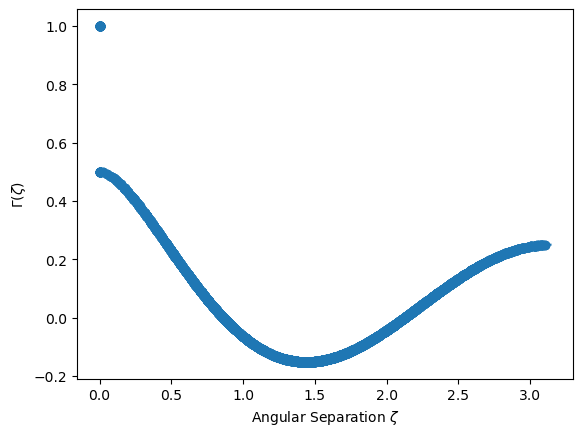

In [18]:
# Init figure
fig, ax = plt.subplots(1)
# Select axis for plotting
cax = ax
# Plot HD curve
cax.plot(
    zeta_all,
    HD_all
)
# Plot values for our pulsars
cax.scatter(
    zeta,
    Gamma,
)
# Label the figure
cax.set_xlabel(r"Angular Separation $\zeta$")
cax.set_ylabel(r"$\Gamma(\zeta)$")

## Step 4: Take the "square root" of the ORF

Use a Cholesky Transform as defined after Equation 63 of [Chamberlin 2014](https://arxiv.org/pdf/1410.8256)

In [19]:
# Do the Cholesky Transform
H = np.linalg.cholesky(Gamma)
# Check the shape of the result ([TODO] Unit test)
print(f"H shape should be ({N_PSR}, {N_PSR}): {H.shape}")

H shape should be (67, 67): (67, 67)


## Step 5: Create a random frequency series

In [20]:
# Real values 
Wa = rng.normal(size=(N_PSR, N_FREQS))
# Complex values
Wb = 1j * rng.normal(size=(N_PSR, N_FREQS))
# Sum real and complex 
# [TODO] Make one line after debugging
W = Wa + Wb
# Check the shape of the result ([TODO] Unit test)
print(f"W shape should be ({N_PSR}, {N_FREQS}): {W.shape}")

W shape should be (67, 100): (67, 100)


## Step 6: Calculate GWB PSD at each frequency

Coefficients $c(f)$, given by Equation 62 of [Chamberlin 2014](https://arxiv.org/pdf/1410.8256) (and substituting in Equation 17)

$c(f)=\left[\frac{T}{48 \pi^2} A_{GWB}^2 \left( \frac{f}{f_{1yr}} \right)^{2\alpha} |f|^{-3}\right]^{\frac{1}{2}}$

In [21]:
C = np.sqrt(
    (obs_dur_s/(48*np.pi**2))
    * A_GWB**2
    * (f/REF_FREQ) ** (2*ALPHA_GWB)
    / (np.abs(f)**3)
)
# Check the shape of the result ([TODO] Unit test)
print(f"C shape should be ({N_FREQS},): {C.shape}")

C shape should be (100,): (100,)


### Unused calculations

I wrote these while trying to figure out what was going on with the different strain equations. Leaving them so I can use these functions again without rewriting them. 

The characteristic strain of the GWB, Equation 14 of [Chamberlin 2014](https://arxiv.org/pdf/1410.8256)

$h_c(f) = A_{GWB} \left( \frac{f}{f_{1yr}} \right)^{\alpha}$

In [22]:
# Characteristic strain of the GWB
h_c = A_GWB * (f / REF_FREQ)**(ALPHA_GWB)
# Check the shape of the result ([TODO] Unit test)
print(f"h_c shape should be ({N_FREQS},): {h_c.shape}")

h_c shape should be (100,): (100,)


Strain spectral density, Equation 15 of [Chamberlin 2014](https://arxiv.org/pdf/1410.8256)

$S_h(f) = \frac{h_c^2(f)}{f}$

In [23]:
# Strain spectral density of the GWB
S_h = (h_c ** 2) / f
# Check the shape of the result ([TODO] Unit test)
print(f"S_h shape should be ({N_FREQS},): {S_h.shape}")

S_h shape should be (100,): (100,)


GWB power spectrum, given by Equation 35 of [Chamberlin 2014](https://arxiv.org/pdf/1410.8256)

In [24]:
# GWB power spectrum
P = A_GWB**2 / (12 * np.pi**2) * (f / REF_FREQ)**(2 * ALPHA_GWB) * f**(-3)
# Check the shape of the result ([TODO] Unit test)
print(f"P shape should be ({N_FREQS},): {P.shape}")

P shape should be (100,): (100,)


## Step 7: Compute the timing residuals in the Fourier domain

The timing residuals in the Fourier domain are given by Equation 57 of [Chamberlin 2014](https://arxiv.org/pdf/1410.8256) as

$r_{a}(f)=c(f) \sum_{b} H_{ab}w_{b}(f)$

In [25]:
# Timing residuals (Fourier domain)
R = (C**0.5) * (H @ W)
# Remove Nyquist bin
R = R[:,0:-1]
# Check the shape of the result ([TODO] Unit test)
print(f"R shape should be ({N_PSR}, {N_FREQS-1}): {R.shape}")

R shape should be (67, 99): (67, 99)


## Step 8: Bring back to time domain

In [26]:
# Array of residuals
Res_f2 = np.hstack([R, np.conj(R)])
# Compute the FFT
Res_t = np.real(np.fft.ifft(Res_f2) / dt)
# Check the shape of the results ([TODO] Unit test)
print(f"Res_f2 shape should be ({N_PSR}, {2*N_FREQS-2}): {Res_f2.shape}")
print(f"Res_t shape should be ({N_PSR}, {2*N_FREQS-2}): {Res_t.shape}")

Res_f2 shape should be (67, 198): (67, 198)
Res_t shape should be (67, 198): (67, 198)


## Step 9: Interpolate onto TOAs

[TODO] Add option for real TOAs, not just fake ones

In [27]:
# Maximum t for interpolation (called x to not reuse variables)
max_interp_x = Res_t.shape[1]
# List of times on which to interpolate
interp_x = np.arange(0, max_interp_x)
# List of TOAs on which to EVALUATE interpolation
interp_t = np.linspace(0, max_interp_x-1, N_TOA)
# Interpolate the residuals
R_interp = interp1d(interp_x, Res_t, axis=1)
# Evaluate the interpolation on TOAs
R_interp_vals = R_interp(interp_t)
# Check the shape of the result ([TODO] Unit test)
print(f"R_interp_vals shape should be ({N_PSR}, {N_TOA}): {R_interp_vals.shape}")

R_interp_vals shape should be (67, 100000): (67, 100000)


Text(0, 0.5, 'Residual ($\\mu s$)')

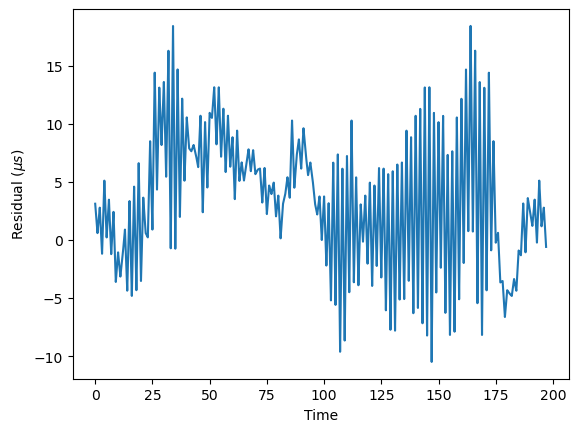

In [28]:
# Init the figure
fig, ax = plt.subplots(1)
# Select axis for plotting
cax = ax
# Plot TOAs vs Residuals (us)
# [TODO] Convert TOAs to actual MJDs or whatever
cax.plot(interp_t, R_interp_vals[0]*1E6)
# Label the axes
cax.set_xlabel("Time")
cax.set_ylabel(r"Residual ($\mu s$)")

## Step 10: Add white noise

[TODO] Find WN values that are physically-motivated

In [29]:
# WN STD value for each pulsar
SIGMAS = rng.uniform(1E-6, 2E-6, N_PSR)
# Repeat N_TOA times to make a matrix
SIGMAS = np.repeat(SIGMAS.reshape(-1, 1), N_TOA, axis=1)
# WN batrix based on given STDs
WN = rng.normal(scale=SIGMAS, size=(N_PSR, N_TOA))
# Add white noise to residuals
R_GWB_WN = R_interp_vals + WN

Text(0, 0.5, 'Residual ($\\mu s$)')

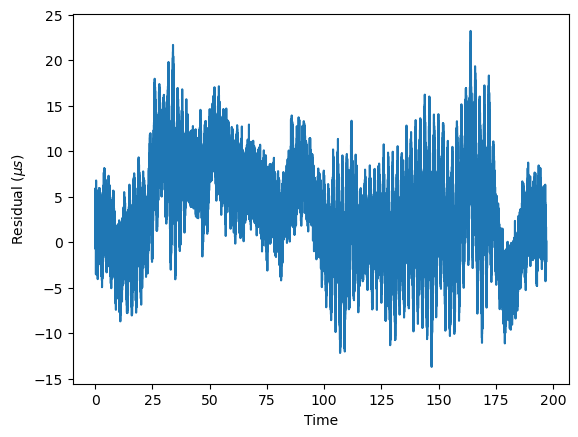

In [30]:
# Init the figure
fig, ax = plt.subplots(1)
# Select current axis
cax = ax
# Plot TOAs vs new Residuals (us)
cax.plot(interp_t, R_GWB_WN[0]*1E6)
# Label axes
cax.set_xlabel("Time")
cax.set_ylabel(r"Residual ($\mu s$)")

## Steps 11-13: Add other noise (incomplete)

### Step 11: Add red noise

Remove Nyquist frequency

[TODO] Clean up when this happens (also done in initial residual calc)

In [31]:
f = f[0:-1]
# Check the shape of the result ([TODO] Unit test)
print(f"f shape should be ({N_FREQS-1},): {f.shape}")

f shape should be (99,): (99,)


The Fourier design matrix is defined in Equation 11 of [Lentati 2011](https://arxiv.org/pdf/1210.3578) as

$F_{\nu,t}=\mathrm{sin}(\frac{2\pi}{T}\nu t)$

with equivalent cosine terms, resulting in an overall matrix size of (`N_TIMES`, 2*`N_FREQS`). 

To get my units right, I'm just doing

$F_{f,t}=\mathrm{sin}(2\pi f t)$

**Question: Is that right? Are these the same frequencies as used elsewhere?**

[TODO] I noticed in `pta_replicator`, there is an option for a `libstempo` convention, which starts with a cosine term instead of a sine term. This can be added by having a boolean argument to swap the column definitions below.

In [32]:
# Init F array (to be filled in)
F = np.zeros((N_TIMES, 2*N_FREQS-2))
# Compute argument for sine and cosine
F_arg = 2 * np.pi * np.outer(t, f) * u.rad
# Sine terms on even columns
F[:, 0::2] = np.sin(F_arg)
# Cosine terms on odd columns
F[:, 1::2] = np.cos(F_arg)
# Clear up memory
del F_arg
gc.collect()
# Check the shape of the result ([TODO] Unit test)
print(f"F shape should be ({N_TIMES}, {2*N_FREQS-2}): {F.shape}")

F shape should be (200, 198): (200, 198)


Define a matrix of frequencies

In [33]:
Ff = np.repeat(f, 2)
# Check the shape of the result ([TODO] Unit test)
print(f"Ff shape should be ({2*N_FREQS-2},): {Ff.shape}")

Ff shape should be (198,): (198,)


### Step 12: Add measurement noise

### Step 13: Add jitter

## Step 14: Check correlations

In [34]:
# Subtract mean from each pulsar
R_zeroed = R_GWB_WN - R_GWB_WN.mean(axis=1, keepdims=True)

# Compute covariance
RC = R_zeroed @ R_zeroed.T / R_zeroed.shape[1]

# Normalize to correlation coefficients
std = np.sqrt(np.diag(RC))
corr = RC / np.outer(std, std)

In [35]:
# Define bin edges
bins = np.linspace(0, np.pi, N_HD_BINS + 1)
# Define bin centers (for plotting)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
# Init lists for mean and error
binned_means = np.zeros(N_HD_BINS)
binned_errors = np.zeros(N_HD_BINS)
# Only look at upper half of matrix (to avoid duplicates)
# k=0 includes the diagonal
mask_triu = np.triu(np.ones_like(zeta, dtype=bool), k=0)
# Go through each bin
# [TODO] Can this be vectorized further?
for i in range(N_HD_BINS):
    # Only look at points in that bin
    mask = mask_triu & (zeta >= bins[i]) & (zeta < bins[i+1])
    # If there are any points in that bin...
    if np.sum(mask) > 0:
        # Pull values in the bin
        vals = corr[mask]
        # Compute the mean
        binned_means[i] = np.mean(vals)
        # Compute the error (1 sigma)
        binned_errors[i] = np.std(vals) / np.sqrt(len(vals))

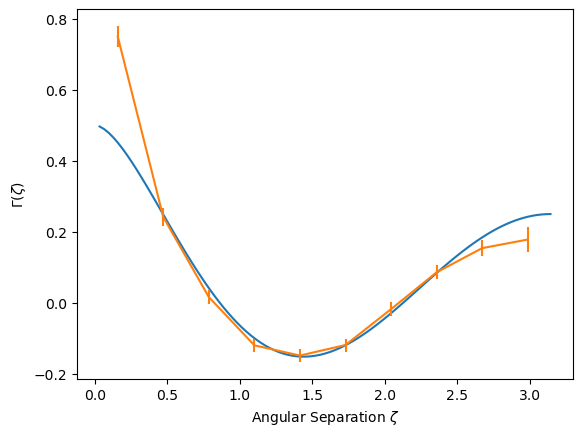

In [36]:
# Init figure
fig, ax = plt.subplots(1)
# Select axis for plotting
cax = ax
# Plot HD curve
cax.plot(
    zeta_all,
    HD_all
)
# Plot binned values
cax.errorbar(
    bin_centers,
    binned_means,
    yerr=binned_errors,
)
# Label the figure
cax.set_xlabel(r"Angular Separation $\zeta$")
cax.set_ylabel(r"$\Gamma(\zeta)$")
print()

## Notebook Cleanup

Stop the timer

In [37]:
t1 = perf_counter()
print(f"Notebook runtime: {t1-t0:.2f} seconds")

Notebook runtime: 10.77 seconds
